# Filtering for SACAIR runs to capture results

Also see the companion benchmarking [notebook.](./benchmark.ipynb).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# locals
from src.results import fetch_runs  # , load_runs
from src.run_types import CUTOFF_9_NAMES, RESULTS_DIR, RESULTS_OUTPUTS
from src.visualise2 import plot_loss_curves, save_fig, set_thesis_style


In [2]:
project_name = 'sacair_2026'
results_dir = RESULTS_DIR / project_name
output_dir = RESULTS_OUTPUTS / project_name
# runs = load_runs(results_dir / 'runs.json')
runs = fetch_runs(results_dir / 'filters.py')
print(f'{len(runs)} found')

21 found


## Now we can compare the runs

In [3]:
avail_acc_types = ["top_k_average_per_class_acc", "top_k_per_instance_acc"]
acc_type = avail_acc_types[1]
set_names = ['test', 'val']

#### Convert to DataFrame

In [4]:
df_format = [
    {
        "model": run.admin.model,
        "exp no": run.admin.exp_no,
        "run_id": run.wandb.run_id,
        "No. frames": run.data.target_length,
        "subset": run.admin.split,
    }
    | {f'{set_name} {k}': v for set_name in set_names for k, v in run.results.model_dump()[set_name][acc_type].items()}
    | {
        "best_val_acc": run.results.best_val_acc,
        "best_val_loss": run.results.best_val_loss,
        "test_loss": run.results.test.average_loss,
        "config path": run.admin.config_path,
        "weight path": run.admin.weight_path,
        }
    for run in runs
]


df = pd.DataFrame(df_format)

In [5]:
ns = [1, 5, 10]
for set_name in set_names:
    for n in ns:
        old_name, new_name = f"{set_name} top{n}", f"{set_name.capitalize()} Top-{n}"

        df = df.rename(columns={old_name: new_name})
        df[new_name] = df[new_name].apply(lambda x: f"{x * 100:.2f}")

# df

In [6]:
subsets = CUTOFF_9_NAMES
# subsets = get_avail_splits()
for set_name in subsets:
    subdf = df[df['subset'] == set_name]
    print(f'{set_name}'.capitalize())
    # display(subdf.sort_values('Test Top-1', ascending=False))
    # display(subdf.sort_values('best_val_loss', ascending=True))
    display(subdf.sort_values('test_loss', ascending=True))

Asl100_cutoff_9


,model,exp no,run_id,No. frames,subset,Test Top-1,Test Top-5,Test Top-10,Val Top-1,Val Top-5,Val Top-10,best_val_acc,best_val_loss,test_loss,config path,weight path
19,MViTv2_B_32x3,007,mi50bgp8,32,asl100_cutoff_9,77.52,93.41,96.51,78.99,94.97,96.75,80.473373,0.854901,0.919939,configfiles/asl100/MViTv2_B_32x3/exp007.toml,None
5,MViTv2_S_16x4_e,000,wifpnh92,32,asl100_cutoff_9,78.68,91.47,95.35,78.40,94.38,97.04,78.402367,0.901107,0.939804,configfiles/asl100/MViTv2_B_32x3/exp007.toml,None
20,MViTv2_B_32x3,001,079ju1dh,32,asl100_cutoff_9,73.26,92.64,95.74,77.81,94.08,97.04,81.360947,0.844280,0.969602,configfiles/asl100/MViTv2_B_32x3/exp001.toml,None
4,MViTv2_S_16x4_e,000,due3auwd,32,asl100_cutoff_9,75.97,91.47,95.74,74.56,94.08,97.34,77.810651,0.899458,0.992132,configfiles/asl100/MViTv2_B_32x3/exp007.toml,None
15,MViTv2_S_16x4,003,86cdpg62,16,asl100_cutoff_9,73.64,91.47,96.12,76.92,93.20,96.75,76.923077,0.925181,1.096831,configfiles/asl100/MViTv2_S_16x4/exp003.toml,None
0,MViTv2_S_16x4,003,qr3tw8i0,16,asl100_cutoff_9,70.16,91.86,94.96,72.49,92.90,97.04,75.147929,1.015559,1.139271,configfiles/asl100/MViTv2_S_16x4/exp003.toml,None
6,MViTv2_B_32x3_r,000,44hymv5q,16,asl100_cutoff_9,72.09,90.70,94.19,73.37,93.49,95.56,75.739645,0.971873,1.177712,configfiles/asl100/MViTv2_S_16x4/exp003.toml,None
7,MViTv2_B_32x3_r,000,xjsc2bqu,16,asl100_cutoff_9,71.71,89.15,94.19,70.41,92.60,96.15,75.147929,1.047918,1.186892,configfiles/asl100/MViTv2_S_16x4/exp003.toml,None


Asl300_cutoff_9


,model,exp no,run_id,No. frames,subset,Test Top-1,Test Top-5,Test Top-10,Val Top-1,Val Top-5,Val Top-10,best_val_acc,best_val_loss,test_loss,config path,weight path
18,MViTv2_B_32x3,000,mgjsrgqn,32,asl300_cutoff_9,67.07,88.77,92.22,72.70,92.12,95.78,72.918979,1.085137,1.364747,configfiles/asl300/MViTv2_B_32x3/exp000.toml,runs/asl100_cutoff_9/MViTv2_B_32x3/exp007/chec...
14,MViTv2_S_16x4,000,v8x1dmue,16,asl300_cutoff_9,60.93,88.02,92.51,66.48,89.46,93.01,68.368479,1.292044,1.564197,configfiles/asl300/MViTv2_S_16x4/exp000.toml,runs/asl100_cutoff_9/MViTv2_S_16x4/exp003/chec...


Asl1000_cutoff_9


,model,exp no,run_id,No. frames,subset,Test Top-1,Test Top-5,Test Top-10,Val Top-1,Val Top-5,Val Top-10,best_val_acc,best_val_loss,test_loss,config path,weight path
17,MViTv2_B_32x3,000,5fj94635,32,asl1000_cutoff_9,56.77,83.48,89.66,58.82,85.81,91.12,60.284605,1.781256,1.922579,configfiles/asl1000/MViTv2_B_32x3/exp000.toml,runs/asl300_cutoff_9/MViTv2_B_32x3/exp000/chec...
13,MViTv2_S_16x4,000,t2zzkxg9,16,asl1000_cutoff_9,51.12,79.37,86.19,52.95,81.54,88.66,54.808107,1.980439,2.156511,configfiles/asl1000/MViTv2_S_16x4/exp000.toml,runs/asl300_cutoff_9/MViTv2_S_16x4/exp000/chec...


Asl2000_cutoff_9


,model,exp no,run_id,No. frames,subset,Test Top-1,Test Top-5,Test Top-10,Val Top-1,Val Top-5,Val Top-10,best_val_acc,best_val_loss,test_loss,config path,weight path
16,MViTv2_B_32x3,000,ap0prl54,32,asl2000_cutoff_9,44.56,76.35,83.71,44.67,77.23,84.94,47.064829,2.492716,2.548980,configfiles/asl2000/MViTv2_B_32x3/exp000.toml,runs/asl1000_cutoff_9/MViTv2_B_32x3/exp000/che...
12,MViTv2_S_16x4,000,f8r7lstq,16,asl2000_cutoff_9,39.91,70.61,79.65,40.68,72.89,81.96,42.700357,2.722687,2.827124,configfiles/asl2000/MViTv2_S_16x4/exp000.toml,runs/asl1000_cutoff_9/MViTv2_S_16x4/exp000/che...
11,MViTv2_S_16x4,001,jxuv2gmx,16,asl2000_cutoff_9,37.65,69.36,80.38,38.51,70.83,80.42,41.220010,2.784146,2.830752,configfiles/asl2000/MViTv2_S_16x4/exp001.toml,None


In [7]:
# Select and rename the columns needed for the thesis table
cols = {
    "model": "Model",
    "No. frames": "Frames",
    "Test Top-1": "Acc@1",
    "Test Top-5": "Acc@5",
    "Test Top-10": "Acc@10",
    "test_loss": "Loss",
}
 
wlasl_100_df = df[df['subset'] == CUTOFF_9_NAMES[0]]

sacair_df = wlasl_100_df[list(cols.keys())].rename(columns=cols)

# Sort by loss (ascending — best/lowest loss first)
sacair_df = sacair_df.sort_values("Loss").reset_index(drop=True)

# Export as CSV 
# sacair_df.to_csv(output_dir / "sacair_results.csv", index=False)

# Export as a LaTeX table (rough draft — formatting/labels will still need cleanup)
latex_str = sacair_df.to_latex(
    index=False,
    float_format="%.2f",
    column_format="lcccc",
    caption="SACAIR 2026 frame count sensitivity results.",
    label="tab:res_sacair_2026",
)
# with open(output_dir / "sacair_results.tex", "w") as f:
#     f.write(latex_str)

# print(sacair_df.to_string(index=False))
# print("\n--- LaTeX ---\n")
# print(latex_str)

## Best val accuracy vs step

In [8]:
set_thesis_style()
csv_path = Path('./best_val_loss.csv')


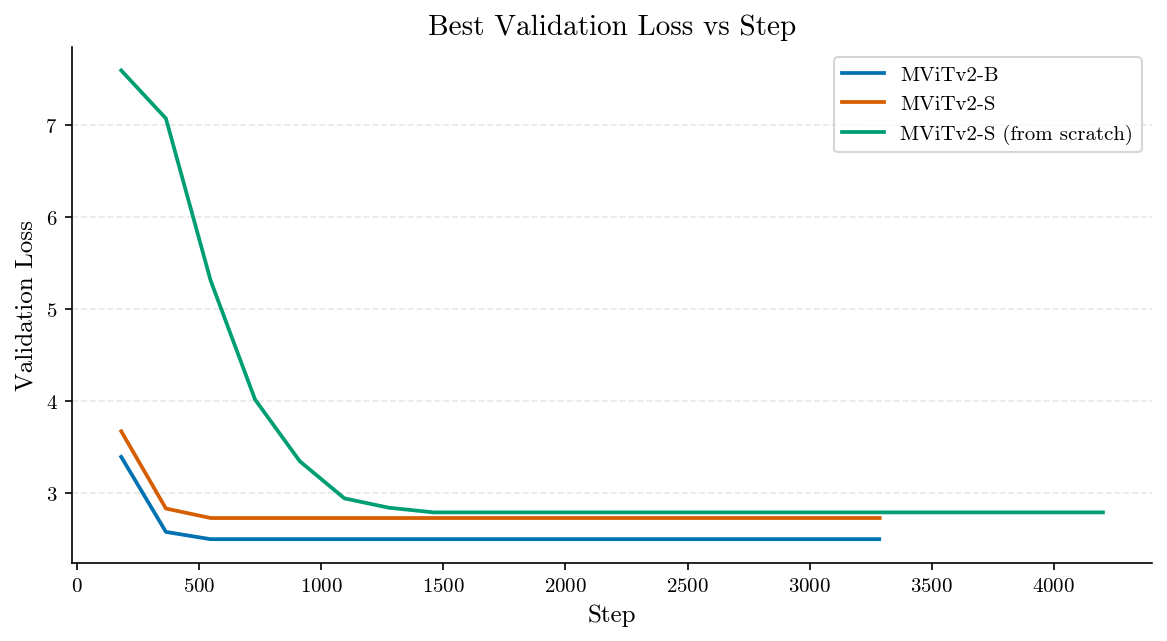

In [9]:
loss_df = pd.read_csv(csv_path)
title = "Best Validation Loss vs Step"
series_cols = [c for c in loss_df.columns if c != "Step"]
_fig, ax = plot_loss_curves(
    loss_df["Step"],
    {col: loss_df[col] for col in series_cols},
    title=title,
    xlabel="Step",
    ylabel="Validation Loss",
)
save_fig(_fig, (output_dir /  title.replace(' ', '_')).with_suffix('.pdf'))
plt.show()